# Knowledge distillation with Vision Transformers

Applying knowledge distillation techniques to the oxford-pets datasets, adataset with 37 classes of dogs and cats


In [1]:
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    ViTConfig,
    ViTForImageClassification,
    ViTImageProcessor,
    TrainingArguments,
    Trainer,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import matplotlib.pyplot as plt

Knowldege from: `asusevski/vit-base-patch16-224-oxford-pets`

Fine tuned model : `google/vit-base-patch16-224` into a randomized `winKwaks/vit-tiny-patch16-224`

Finetune model already has $93%$ accuracy containing this dataset.

In [2]:
# Teacher

dataset=load_dataset("pcuenq/oxford-pets")

README.md:   0%|          | 0.00/565 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

data/train-00000-of-00001-ecc2afb43dedd5(…): reconstructing file:   0%|          |  0.00B /  234MB            

data/train-00000-of-00001-ecc2afb43dedd5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7390 [00:00<?, ? examples/s]

In [3]:
id2label={int_label:str_label for int_label, str_label in enumerate(sorted(list(set(dataset["train"]["label"]))))}
label2id={str_label:int_label for int_label, str_label in enumerate(sorted(list(set(dataset["train"]["label"]))))}


Training (Ground Truth): The model needs label2id so it can convert human labels into integers (e.g., class 0 or 1) to calculate loss and update its weights during backpropagation.

<br>

Inference (Predictions): When the model finishes training and guesses an output (like the number 0), it uses id2label to translate that number back into a readable format so a human user can see text like "cat" instead of a raw index.

In [4]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model_name="asusevski/vit-base-patch16-224-oxford-pets"
teacher_model=AutoModelForImageClassification.from_pretrained(teacher_model_name).to(device)
teacher_model.eval()

config.json:   0%|          | 0.00/2.48k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [5]:
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [6]:
import evaluate

processor=ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
accuracy=evaluate.load("accuracy")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

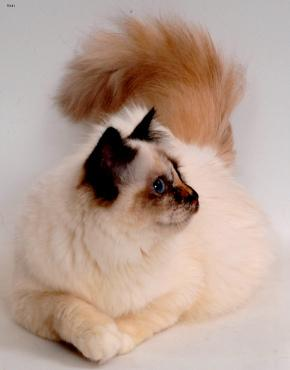

In [7]:
dataset["train"][1]["image"]

In [8]:
inputs=processor(dataset["train"][0]["image"],return_tensors="pt") # using default processor on the image
inputs={key:value.to(device) for key,value in inputs.items()}

model_logits=teacher_model(**inputs).logits
model_prediction=torch.argmax(model_logits,dim=1).item()
print(id2label[model_prediction])

Siamese


Deep learning models output raw scores called logits rather than percentages. A higher logit means the model assigns a higher confidence to that specific class.


Argmax Selection: Because the model outputs a score for every single category it knows, torch.argmax acts as a selector, picking the single class index with the highest score and throwing away the rest.


The teacher_model naming: In advanced computer vision workflows, a "teacher model" is a massive, highly accurate network. Code like this is often used to extract predictions from the teacher model to supervise a smaller, faster "student model" (a process called knowledge distillation).


The Problem: Teacher models are too confident. They say "99% cat, 0% toaster" and hide helpful clues.

The Solution: Temperature ($T$) is a dial that softens those extreme scores so the student model can learn from the "wrong" answers.

Low Temp ($T=2$): Keeps the main answer mostly dominant. (Sharp focus)


High Temp ($T=8$): Flattens the scores, forcing the student to notice subtle hints—like realizing a Siamese cat looks way more like a regular cat than a toaster.


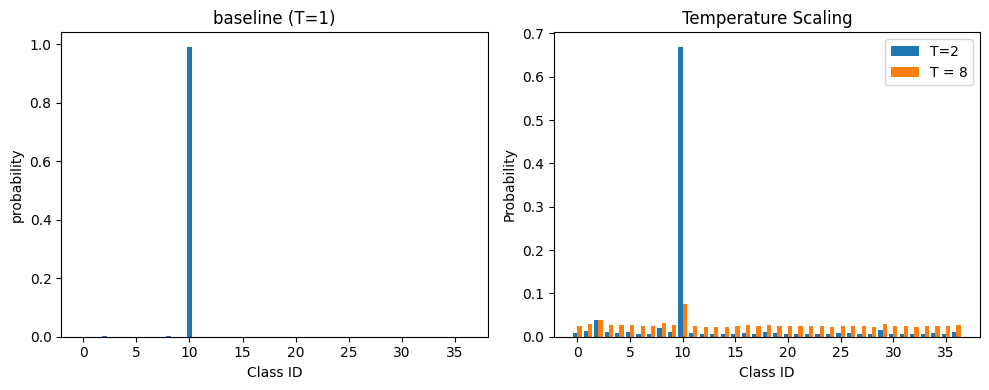

In [9]:
temperature_no_change=1
low_temperature=2
high_temperature=8

# It temperature-scales and converts raw model logits into a flattened, CPU-safe NumPy array of probabilities.
teacher_distribution=F.softmax(model_logits/temperature_no_change,dim=-1).cpu().detach().numpy().reshape(-1)
teacher_distribution_low_temp = F.softmax(model_logits / low_temperature, dim=-1).cpu().detach().numpy().reshape(-1)
teacher_distribution_high_temp = F.softmax(model_logits / high_temperature, dim=-1).cpu().detach().numpy().reshape(-1)

x=np.arange(len(teacher_distribution))
width=0.4

fig,axs=plt.subplots(1,2,figsize=(10,4))

axs[0].bar(x,teacher_distribution,width=0.5)
axs[0].set(title="baseline (T=1)", ylabel="probability", xlabel="Class ID")

axs[1].bar(x-width/2, teacher_distribution_low_temp,width=width, label="T=2")
axs[1].bar(x + width/2, teacher_distribution_high_temp, width=width, label='T = 8')
axs[1].set(title="Temperature Scaling", ylabel="Probability", xlabel="Class ID")
axs[1].legend()

plt.tight_layout()
plt.show()

Temperature scaling turns a very confident prediction into a softer probability distribution, while keeping the most likely class the same.


| Observation                | Interpretation                          |
| -------------------------- | --------------------------------------- |
| Class 10 stays the largest | **Prediction/ranking is preserved**     |
| T increases                | Distribution becomes **softer**         |
| T=1 → very peaked          | Model is **highly confident**           |
| T=2 → less peaked          | Model expresses **less confidence**     |
| T=8 → nearly flat          | Model expresses **very low confidence** |


> Temperature scaling changes confidence, not the underlying class preference.



Mathematically,

$$ p_i(T)=\frac{e^{z_i/T}}{\sum_j e^{z_j/T}} $$

where \(z_i\) is the model's logit.

```
T = 1: normal softmax
T > 1: flatten probabilities
T < 1: sharpen probabilities
```


> Increasing the distillation temperature progressively softens the teacher's output distribution while preserving the top-ranked class, providing the student with richer information about inter-class similarities; however, an appropriate temperature should be selected empirically based on validation performance and calibration rather than visual smoothness alone.

----


Now we have to prepare the data for ingestion by the HuggingFace Trainer. We prepared the inputs by using the ViTImageProcessor class above, but we also need to preprare the labels for training. These transforms will be written in the function transforms and we will map the transforms to each observation in the dataset.

In [10]:
def transforms(example):

  # convert to RGB
  example["image"]=example["image"].convert("RGB")

  # feed image into ViT image processor

  inputs=processor(example["image"],return_tensors="pt")

  # add to example

  example["pixel_values"]=inputs["pixel_values"].squeeze()
  example["label"]=label2id[example["label"]]
  return example

In [11]:
transformed_dataset=dataset.map(transforms)
transformed_dataset.set_format("pt", columns=["pixel_values"],output_all_columns=True)

Map:   0%|          | 0/7390 [00:00<?, ? examples/s]

In [12]:
def collate_fn(batch):
  return {
      "pixel_values":torch.cat([x["pixel_values"].unsqueeze(dim=0) for x in batch],dim=0),
      "labels":torch.tensor([x["label"] for x in batch])
  }

```
Original dataset = 100%
        │
        ├── 20% → TEST
        │
        └── 80% → split again
                    │
                    ├── 10% → VALIDATION
                    │
                    └── 70% → TRAIN
            final student

T = 1  → teacher says "Class 10!"
T = 2  → teacher gives more information
T = 4  → softer information
T = 8  → very soft information

```
> 🌡️ Temperature softens the teacher's predictions.

> 🎯 Optimization finds the temperature that works best.

In [13]:
# splitting the dataset into train validation and test (Soften = reduce the teacher's certainty.)

# 80% development + 20% test
train_test_dataset=transformed_dataset["train"].train_test_split(test_size=0.2) # This gives: 80% → train  20% → test

# Split the 80% again:
train_val_dataset=transformed_dataset["train"].train_test_split(0.1/0.8)  # Why 0.125? Because we want 10% of the original dataset for validation

# So 12.5% of the remaining 80% = 10% of the original.
train_test_valid_dataset=DatasetDict({
    "train":train_val_dataset["train"],
    "valid":train_val_dataset["test"],
    "test":train_test_dataset["test"]
})



# "Take the 70% train, 10% validation, and 20% test that I already created, and give them convenient names inside one DatasetDict."

Instead of asking:

> "Does knowledge distillation make the student better ?

we need to know:

> " How good is the student if i just train it normally ?

thats baseline


start with

```
WinKawaks/vit-tiny-patch16-224
```
Student sized model, train it normally for 5 epochs using training data:

```
Training images
      ↓
ViT-Tiny
      ↓
learns normally
      ↓
Baseline performance
```

and compare agianst

```
ViT-Tiny + Teacher
       ↓
  distillation
       ↓
performance
```

Hugging Face `Trainer` is training manager.

> Here is my model and here is how i wnat to train it and here is how i want to measure it.



ViTconfig

> "Give me the architecture, but don't give me its learned knowledge."

First, train a small ViT normally for 5 epochs. This gives us a baseline. Then later, we'll train another ViT using knowledge from the teacher and see whether distillation improves it. Hugging Face's Trainer handles the training process. We give it the model, training settings, evaluation method, and then let it trai

In [14]:
config=ViTForImageClassification.from_pretrained("WinKawaks/vit-tiny-patch16-224").config
config.id2label=id2label
config.label2id=label2id
config.num_labels=len(id2label)
base_model=ViTForImageClassification(config).to(device)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
training_args = TrainingArguments(
    output_dir="oxford-pets-vit-from-scratch",
    per_device_train_batch_size=48,  #The model looks at 48 images at a time before updating its weights.
    per_device_eval_batch_size=48,
    eval_strategy="epoch", #Let's check how well the model is doing."
    save_strategy="epoch",
    logging_steps=100,
    num_train_epochs=10, #The model goes through the training dataset 10 times.
    learning_rate=3e-4,  #How aggressively should the model change what it has learned?
    push_to_hub=False,
    load_best_model_at_end=True,   #"Don't necessarily keep the model from epoch 10. Give me the best checkpoint."
)

In [16]:
accuracy = evaluate.load("accuracy") #How many predictions did the model get right?

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    acc = accuracy.compute(references=labels, predictions=np.argmax(predictions, axis=1))
    return {"accuracy": acc["accuracy"]}

if a model gets something like this
```
Class 0 → 0.1
Class 1 → 0.05
Class 2 → 0.80  ← highest
Class 3 → 0.05

```
np.argmax() picks the biggest one:
```
Prediction = Class 2
```
then compare:

```
Prediction: Class 2
True label: Class 2

✅ Correct
```
Trained then calculates accuracy acorss all the images



In [17]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224") # Raw image → resize/normalize → format ViT understands

trainer = Trainer(
    model=base_model,
    args=training_args,
    train_dataset=train_test_valid_dataset["train"],
    eval_dataset=train_test_valid_dataset["test"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=image_processor,
)

# It creates the Trainer by putting together the model, training settings, training data, evaluation data, image-processing function, and accuracy metric so the model can be trained and evaluated.

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,3.626773,3.560642,0.045332
2,3.568224,3.517241,0.053451
3,3.477199,3.419735,0.072395
4,3.428462,3.355726,0.113667
5,3.383295,3.290584,0.102842
6,3.276650,3.187050,0.138024
7,3.212083,3.133434,0.135995
8,3.159797,3.046159,0.164411
9,3.046449,2.994711,0.182003
10,3.011236,2.960770,0.202977


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=1350, training_loss=3.3063963713469326, metrics={'train_runtime': 4267.6185, 'train_samples_per_second': 15.151, 'train_steps_per_second': 0.316, 'total_flos': 3.2303652812476416e+17, 'train_loss': 3.3063963713469326, 'epoch': 10.0})

```
                    Trainer
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
     MODEL          SETTINGS        DATASETS
   ViT-Tiny        10 epochs       TRAIN 70%
                     LR             VALID 10%
                   batch 48         TEST 20%
                       │
                       ↓
                  TRAIN MODEL
                       │
                       ↓
                  Check accuracy
```

In [19]:
trainer.evaluate(train_test_valid_dataset["test"])

Training Loss,Validation Loss,Epoch,Accuracy
3.011236,2.960770,10,0.202977


{'eval_loss': 2.96077036857605, 'eval_accuracy': 0.2029769959404601}

```
Where We Stand Right Now

Baseline Accuracy: ~11.6% after training a fresh Vision Transformer (ViT) from scratch for 10 epochs.

The Context: There are 37 classes total. Pure random guessing would get you ~2.7%, so 11.6% means the model is successfully learning—but it has plenty of room to grow!

Leveling Up with Knowledge Distillation
We are going to train a brand-new ViT from scratch, but this time with a cheat code: Knowledge Distillation.

```

In [20]:
student_model=ViTForImageClassification(config).to(device)

```
The Secret Sauce (ImageDistilTrainer)

The Custom Trainer: Instead of the regular Trainer, we use a modified class called ImageDistilTrainer.

Rewriting the Loss: We swap out the default loss function to track distillation loss alongside standard classification loss.

The Mix: The final loss combines both types using a weighted average controlled by lambda_param.
```

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

class ImageDistilTrainer(Trainer):
    def __init__(self, teacher_model=None, student_model=None, temperature=None, lambda_param=None,  *args, **kwargs):
        super().__init__(model=student_model, *args, **kwargs)
        self.teacher = teacher_model
        self.student = student_model
        self.loss_function = nn.KLDivLoss(reduction="batchmean")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.teacher.to(device)
        self.teacher.eval()
        self.temperature = temperature
        self.lambda_param = lambda_param

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        student_output = model(**inputs)

        with torch.no_grad():
            teacher_output = self.teacher(**inputs)

        # Compute soft targets for teacher and student
        soft_teacher = F.softmax(teacher_output.log_softmax / self.temperature if hasattr(teacher_output, 'log_softmax') else teacher_output.logits / self.temperature, dim=-1) # fallback safeguard, keeping your original logits logic:
        soft_teacher = F.softmax(teacher_output.logits / self.temperature, dim=-1)
        soft_student = F.log_softmax(student_output.logits / self.temperature, dim=-1)

        # Compute the loss
        distillation_loss = self.loss_function(soft_student, soft_teacher) * (self.temperature ** 2)

        # Compute the true label loss
        student_target_loss = student_output.loss

        # Calculate final loss
        loss = (1. - self.lambda_param) * student_target_loss + self.lambda_param * distillation_loss
        return (loss, student_output) if return_outputs else loss

This custom trainer supercharges a student model by forcing it to mimic a pre-trained teacher model's "soft" probability outputs instead of just learning from rigid true/false labels. Inside compute_loss, it passes inputs through both the student and the frozen teacher, scales their logits using a temperature parameter to smooth out probabilities, and measures their disagreement using KL divergence multiplied by $T^2$. Finally, it blends this rich distillation insight with the student's regular classification loss using a lambda parameter weight, giving the model a much smarter blueprint for learning than raw data alone.

In [37]:
training_args = TrainingArguments(
    output_dir="oxford-pets-vit-with-kd",
    per_device_train_batch_size=48,  #The model looks at 48 images at a time before updating its weights.
    per_device_eval_batch_size=48,
    eval_strategy="epoch", #Let's check how well the model is doing."
    save_strategy="epoch",
    logging_steps=100,
    num_train_epochs=10, #The model goes through the training dataset 10 times.
    learning_rate=3e-4,  #How aggressively should the model change what it has learned?
    push_to_hub=False,
    load_best_model_at_end=True,   #"Don't necessarily keep the model from epoch 10. Give me the best checkpoint."
)

In [38]:
teacher_model.eval()

trainer = ImageDistilTrainer(
    student_model=base_model,
    teacher_model=teacher_model,
    args=training_args,
    train_dataset=train_test_valid_dataset["train"],
    eval_dataset=train_test_valid_dataset["test"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=image_processor,
    temperature=5,
    lambda_param=0.9
)


In [42]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,3.492025,3.353635,0.175237
2,3.425537,3.308768,0.195535
3,3.331985,3.251868,0.209066
4,3.283899,3.141872,0.226658
5,3.204696,3.065141,0.263870
6,3.077492,2.995054,0.288904
7,2.998988,2.908862,0.322057
8,2.955316,2.807028,0.343031
9,2.791721,2.727937,0.376184
10,2.747896,2.706063,0.376184


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=1350, training_loss=3.121443413628472, metrics={'train_runtime': 5394.998, 'train_samples_per_second': 11.985, 'train_steps_per_second': 0.25, 'total_flos': 3.33348117887361e+17, 'train_loss': 3.121443413628472, 'epoch': 10.0})

In [43]:
trainer.evaluate(train_test_valid_dataset["test"])

Training Loss,Validation Loss,Epoch,Accuracy
2.747896,2.706063,10,0.376184


{'eval_loss': 2.7060630321502686, 'eval_accuracy': 0.3761840324763194}

In [44]:
from google.colab import drive
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Create ZIP (if you haven't already)
folder = "/content/oxford-pets-vit-with-kd"
shutil.make_archive(folder, "zip", folder)

# 3. Copy to Google Drive
shutil.copy(f"{folder}.zip", "/content/drive/MyDrive/")
print("Done! Go to your Google Drive web page, find 'oxford-pets-vit-with-kdh.zip', and download it from there.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done! Go to your Google Drive web page, find 'oxford-pets-vit-with-kdh.zip', and download it from there.
